# 2 · The model, explained

This notebook walks through the equations (full detail in `docs/model.md`), the finite-volume grid, and one time step solved with **bandsolver**, Newman's BAND method.

## Unknowns and equations

At each node there are four unknowns: electrolyte concentration $c$, solid potential $\Phi_1$, electrolyte potential $\Phi_2$ and the lithium concentration in the particles $c_s$. In the porous cathode:

$$
\varepsilon\frac{\partial c}{\partial t} = -\frac{\partial N_+}{\partial x} + \frac{a\,i_n}{F},\qquad
\frac{\partial i_1}{\partial x} = -a\,i_n,\qquad
\frac{\partial i_2}{\partial x} = a\,i_n,\qquad
\varepsilon_{AM}\frac{\partial c_s}{\partial t} = -\frac{a\,i_n}{F}
$$

with the cation flux and the ionic current of a binary 1:1 electrolyte (dilute-solution theory)

$$
N_+ = -\varepsilon\frac{D_+}{\tau}\frac{\partial c}{\partial x} - \varepsilon\frac{u_+}{\tau}F c\frac{\partial \Phi_2}{\partial x},\qquad
i_2 = -\varepsilon F\frac{D_+ - D_-}{\tau}\frac{\partial c}{\partial x} - \varepsilon F^2\frac{u_+ + u_-}{\tau} c\frac{\partial\Phi_2}{\partial x},
$$

$i_1 = -(1-\varepsilon)\sigma\,\partial\Phi_1/\partial x$, and Butler–Volmer kinetics
$i_n = i_0\left[e^{\alpha_a F\eta/RT} - e^{-\alpha_c F\eta/RT}\right]$ with $\eta = \Phi_1 - \Phi_2 - U(\theta)$.
The separator has only transport. At the lithium foil $N_+ = I/F$ and $\Phi_2 = 0$; at the current collector $i_1 = I$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import bandsolver

from lfp_model import kinetics
from lfp_model.model import Assembler, make_mesh
from lfp_model.params import Params
from lfp_model.simulate import initial_state, newton_step

p = Params(mode="corrected", C_rate=1.0)
m = make_mesh(p)
print(f"{p.nj} nodes; separator/cathode interface at node {m.s}")

101 nodes; separator/cathode interface at node 21


## The grid

Control volumes of width $\Delta x_j$, with zero-volume nodes at the lithium foil, at the separator/cathode interface and at the current collector. Those three nodes carry the boundary and interface conditions.

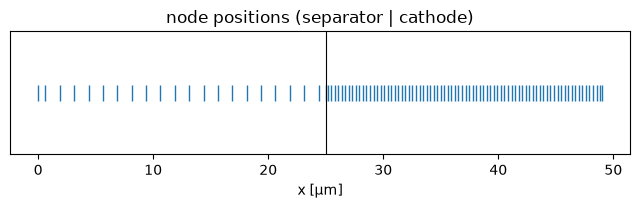

In [2]:
plt.figure(figsize=(8, 1.6))
plt.plot(m.x * 1e4, np.zeros_like(m.x), "|", ms=12)
plt.axvline(p.L_sep * 1e4, color="k", lw=0.8)
plt.xlabel("x [µm]"); plt.yticks([]); plt.title("node positions (separator | cathode)"); plt.show()

## The open-circuit potential and the kinetics

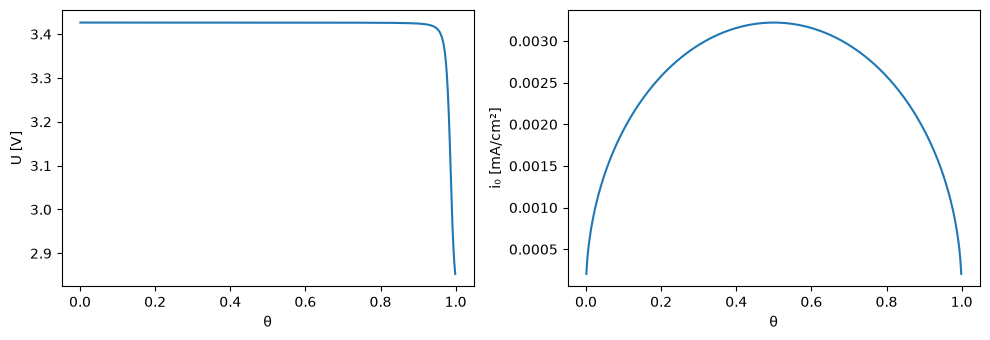

In [3]:
theta = np.linspace(0.001, 0.999, 400)
cs = theta * kinetics.cs_max(p)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(theta, kinetics.ocp(p, cs)); ax[0].set_xlabel("θ"); ax[0].set_ylabel("U [V]")
ax[1].plot(theta, kinetics.exchange_current(p, p.c_bulk, cs) * 1e3)
ax[1].set_xlabel("θ"); ax[1].set_ylabel("i₀ [mA/cm²]")
plt.tight_layout(); plt.show()

## One time step with BAND

Each backward-Euler step is a nonlinear system in block-tridiagonal form, $A_j\,\delta_{j-1} + B_j\,\delta_j + D_j\,\delta_{j+1} = G_j$ with $G = -F(c)$. The assembler builds the blocks, and `bandsolver.solve` solves them. `newton_step` repeats this until the update is below the tolerance.

In [4]:
asm = Assembler(p)
c0 = initial_state(p)
A, B, D, G, _ = asm.assemble(c0, 1.0)
print("block shapes:", A.shape, B.shape, D.shape, G.shape)
dc = bandsolver.solve(A, B, D, G)
print("first-iteration update, max |dΦ1| =", np.abs(dc[:, 1]).max(), "V")

c1, iterations = newton_step(asm, c0, 1.0)
print("Newton converged in", iterations, "iterations")

block shapes: (101, 4, 4) (101, 4, 4) (101, 4, 4) (101, 4)
first-iteration update, max |dΦ1| = 0.12161673827812519 V
Newton converged in 9 iterations


## Checking the Jacobian

`bandsolver.check_jacobian` compares the hand-written Jacobian blocks with finite differences of the residual. The residual here includes the time term of the step from `c0`.

In [5]:
def fill(c):
    A, B, D, G, _ = asm.assemble(c, 1.0)
    return A, B, D, G - asm.time_terms(1.0) * (c - c0)

chk = bandsolver.check_jacobian(fill, c1)
print(f"max relative error {chk.max_error:.1e}")

max relative error 2.3e-04


## Inside the cell during a discharge

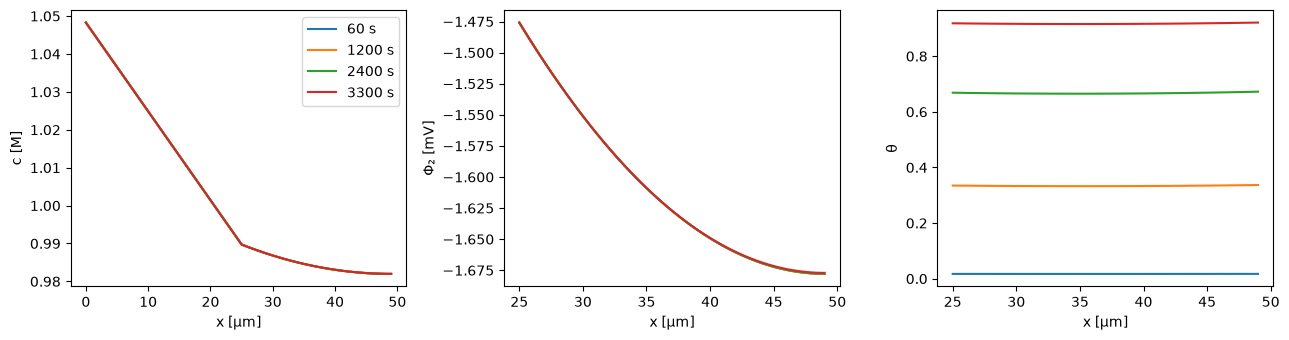

In [6]:
from lfp_model.simulate import run

snapshots = {}
for t_s in (60, 1200, 2400, 3300):
    snapshots[t_s] = run(p, max_steps=t_s).final_state
fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))
for t_s, c in snapshots.items():
    ax[0].plot(m.x * 1e4, c[:, 0] * 1e3, label=f"{t_s} s")
    ax[1].plot(m.x[m.s:] * 1e4, c[m.s:, 2] * 1e3)
    ax[2].plot(m.x[m.s:] * 1e4, c[m.s:, 3] / kinetics.cs_max(p))
ax[0].set_ylabel("c [M]"); ax[1].set_ylabel("Φ₂ [mV]"); ax[2].set_ylabel("θ")
for a_ in ax: a_.set_xlabel("x [µm]")
ax[0].legend(); plt.tight_layout(); plt.show()